# Multi-Dataset Framework Analysis

Comprehensive analysis of agentic framework performance across BBH, ARC, and GSM8K datasets.

In [76]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

plt.style.use('default')
sns.set_palette("husl")
print("📊 Multi-Dataset Framework Analysis")

📊 Multi-Dataset Framework Analysis


In [77]:
# Find latest run and load all results
logs_dir = Path("../logs")
latest_run = max([d for d in logs_dir.iterdir() if d.is_dir() and d.name.startswith("run_")])
print(f"📁 Latest run: {latest_run.name}")

# Parse all log files and extract results
results = []
for log_file in latest_run.glob("*.log"):
    # Parse filename: fm_<framework>_<dataset>_<mode>_<config>.log
    parts = log_file.stem.split("_")
    if len(parts) < 4 or not log_file.stem.startswith("fm_"):
        continue
    
    framework = "_".join(parts[1:-3])
    dataset, mode, config = parts[-3:]
    
    # Extract result path from log
    content = log_file.read_text()
    match = re.search(r"Results saved to: outputs/([^\s]+\.json)", content)
    if not match:
        continue
    
    # Find result file
    for variant in [framework, framework.replace('_', '-')]:
        result_path = Path(f"../frameworks/fm_{variant}/outputs/{match.group(1)}")
        if result_path.exists():
            break
    else:
        continue
    
    # Load and parse result file
    try:
        data = json.loads(result_path.read_text())
    except:
        continue
    
    # Extract questions
    for result in data.get('detailed_results', []):
        row = {
            'framework': framework,
            'dataset': dataset,
            'task': result.get('task', dataset.upper()),
            'is_correct': bool(result.get('is_correct', False)),
            'overall_accuracy': float(data.get('overall_accuracy', 0))
        }
        
        # Add GSM8K reasoning alignment if available
        if dataset.lower() == 'gsm8k' and 'meta' in result:
            alignment = result['meta'].get('reasoning_alignment')
            if alignment is not None:
                row['reasoning_alignment'] = float(alignment)
        
        results.append(row)

df = pd.DataFrame(results)
if not df.empty:
    # Ensure proper data types
    df['is_correct'] = df['is_correct'].astype(bool)
    df['overall_accuracy'] = df['overall_accuracy'].astype(float)
    if 'reasoning_alignment' in df.columns:
        df['reasoning_alignment'] = pd.to_numeric(df['reasoning_alignment'], errors='coerce')

print(f"✅ Loaded {len(df)} questions from {df['framework'].nunique()} frameworks across {df['dataset'].nunique()} datasets")

📁 Latest run: run_20250907_164536
✅ Loaded 300 questions from 25 frameworks across 3 datasets


🧠 BBH Framework Performance:
 1. babyagi         100.0%
 2. langchain       100.0%
 3. anus             83.3%
 4. qwen_agent       83.3%
 5. pydantic         83.3%
 6. livekit          83.3%
 7. mastra           83.3%
 8. langgraph        83.3%
 9. openai-agents    83.3%
10. superagi         83.3%

🎯 BBH Tasks by Difficulty:
🟡 causal_judgement           34.0%
🟢 boolean_expressions        90.0%
🟢 date_understanding         92.0%


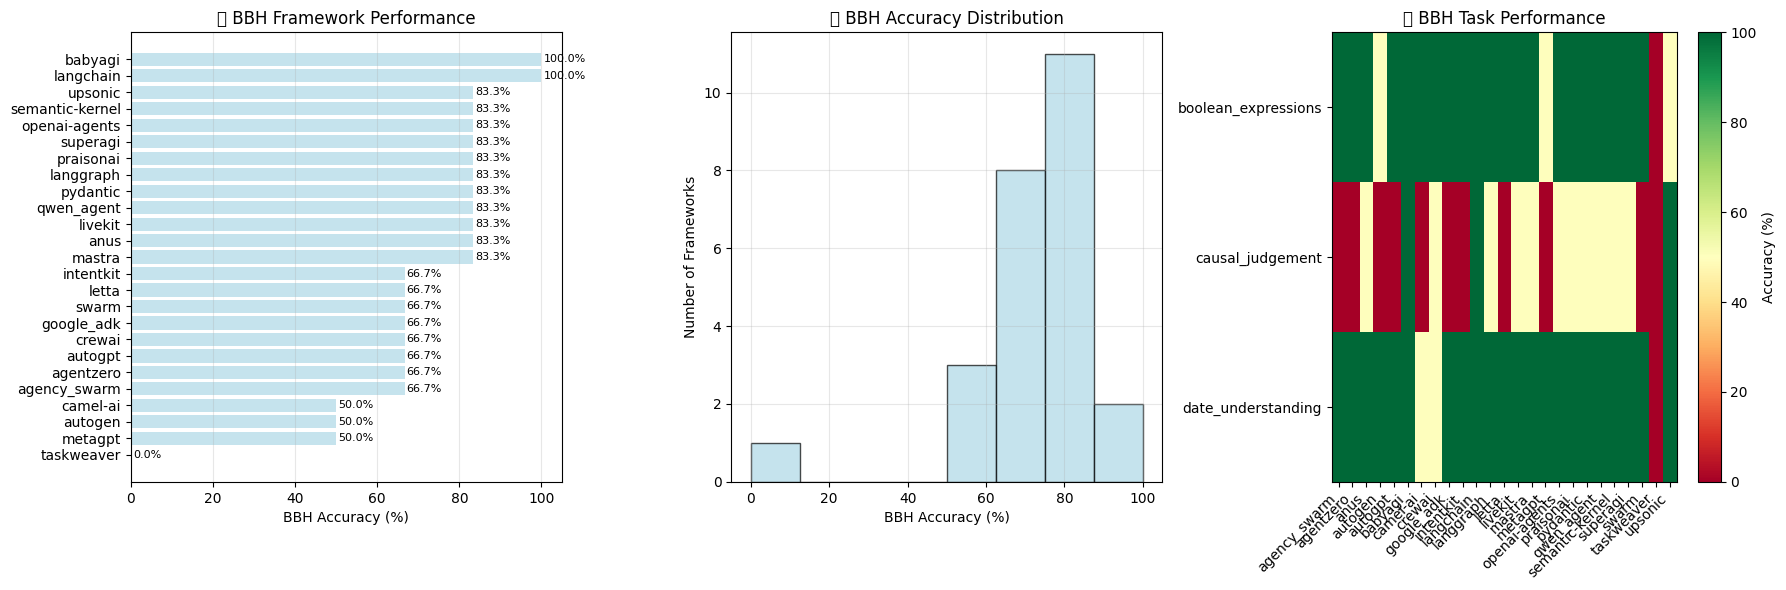

🔬 ARC Framework Performance:
 1. agency_swarm    100.0%
 2. autogen         100.0%
 3. crewai          100.0%
 4. camel-ai        100.0%
 5. babyagi         100.0%
 6. google_adk      100.0%
 7. metagpt         100.0%
 8. openai-agents   100.0%
 9. intentkit       100.0%
10. superagi        100.0%


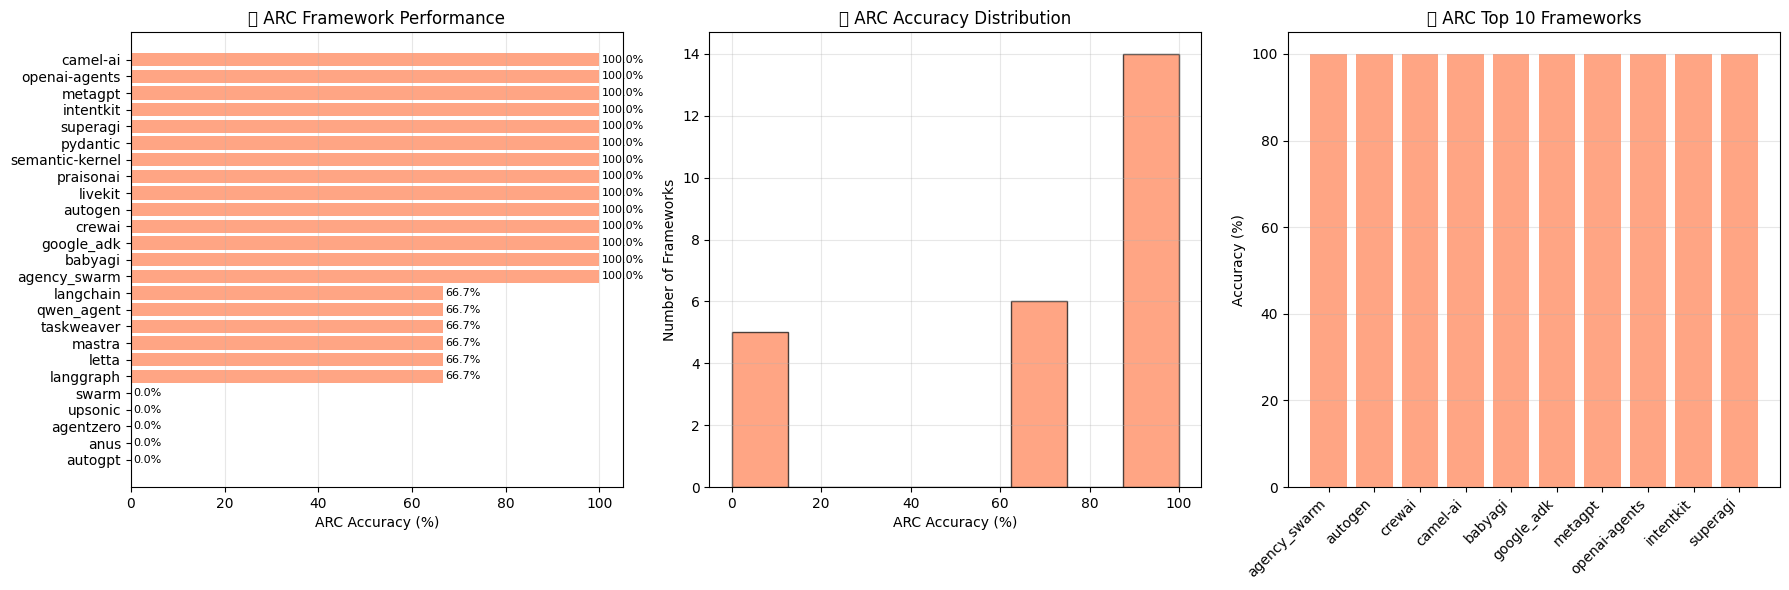

🧮 GSM8K Framework Performance:
 1. agency_swarm    100.0%
 2. agentzero       100.0%
 3. anus            100.0%
 4. autogen         100.0%
 5. autogpt         100.0%
 6. babyagi         100.0%
 7. camel-ai        100.0%
 8. crewai          100.0%
 9. google_adk      100.0%
10. langchain       100.0%


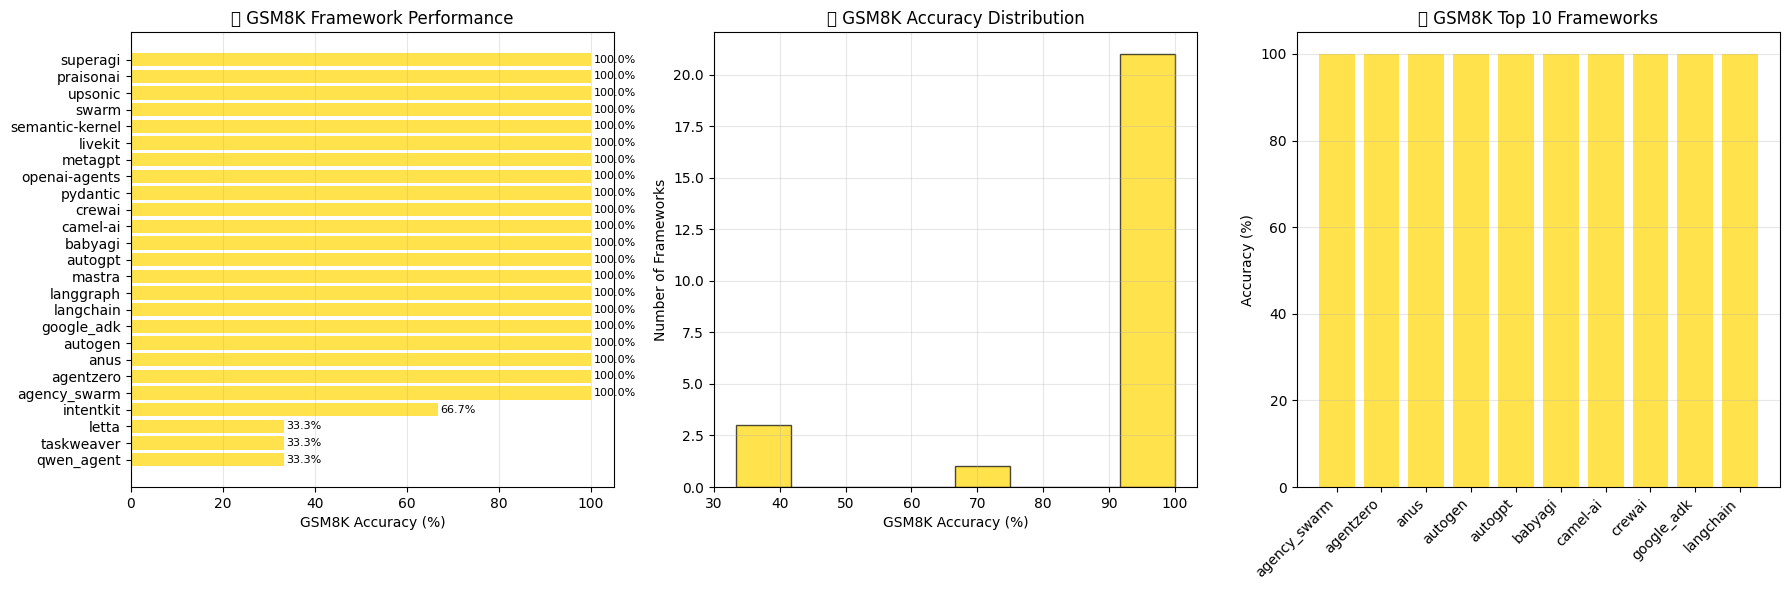

In [78]:
# Unified Dataset Analysis
def analyze_dataset(dataset_name, color='blue', emoji='📊'):
    """Unified analysis function for all datasets"""
    data = df[df['dataset'] == dataset_name.lower()]
    if data.empty:
        print(f"❌ No {dataset_name} data found")
        return
    
    # Framework performance ranking
    perf = data.groupby('framework')['overall_accuracy'].first().sort_values(ascending=False)
    print(f"{emoji} {dataset_name} Framework Performance:")
    for i, (fw, acc) in enumerate(perf.head(10).items(), 1):
        print(f"{i:2d}. {fw:15s} {acc:5.1f}%")
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Horizontal bar chart (performance ranking)
    perf_sorted = perf.sort_values(ascending=True)
    bars = axes[0].barh(perf_sorted.index, perf_sorted.values, color=color, alpha=0.7)
    axes[0].set_xlabel(f'{dataset_name} Accuracy (%)')
    axes[0].set_title(f'{emoji} {dataset_name} Framework Performance')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        width = bar.get_width()
        axes[0].text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{width:.1f}%', ha='left', va='center', fontsize=8)
    
    # 2. Distribution histogram
    axes[1].hist(perf.values, bins=8, alpha=0.7, color=color, edgecolor='black')
    axes[1].set_xlabel(f'{dataset_name} Accuracy (%)')
    axes[1].set_ylabel('Number of Frameworks')
    axes[1].set_title(f'{emoji} {dataset_name} Accuracy Distribution')
    axes[1].grid(alpha=0.3)
    
    # 3. Task-level analysis (if task data available)
    if 'task' in data.columns and len(data['task'].unique()) > 1:
        task_perf = data.groupby(['task', 'framework'])['is_correct'].mean().unstack(fill_value=0) * 100
        im = axes[2].imshow(task_perf.values, aspect='auto', cmap='RdYlGn')
        axes[2].set_xticks(range(len(task_perf.columns)))
        axes[2].set_xticklabels(task_perf.columns, rotation=45, ha='right')
        axes[2].set_yticks(range(len(task_perf.index)))
        axes[2].set_yticklabels(task_perf.index)
        axes[2].set_title(f'{emoji} {dataset_name} Task Performance')
        plt.colorbar(im, ax=axes[2], label='Accuracy (%)')
        
        # Print task difficulty ranking
        task_diff = task_perf.mean(axis=1).sort_values()
        print(f"\n🎯 {dataset_name} Tasks by Difficulty:")
        for task, diff in task_diff.items():
            level = "🟢" if diff > 60 else "🟡" if diff > 30 else "🔴"
            print(f"{level} {task:25s} {diff:5.1f}%")
    else:
        # Simple framework comparison if no task data
        axes[2].bar(range(len(perf.head(10))), perf.head(10).values, color=color, alpha=0.7)
        axes[2].set_xticks(range(len(perf.head(10))))
        axes[2].set_xticklabels(perf.head(10).index, rotation=45, ha='right')
        axes[2].set_ylabel('Accuracy (%)')
        axes[2].set_title(f'{emoji} {dataset_name} Top 10 Frameworks')
        axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name.lower()}_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Analyze all datasets with unified approach
if not df.empty:
    analyze_dataset('BBH', color='lightblue', emoji='🧠')
    analyze_dataset('ARC', color='coral', emoji='🔬') 
    analyze_dataset('GSM8K', color='gold', emoji='🧮')
else:
    print("❌ No data available for analysis")

🧠 GSM8K Reasoning Quality Analysis:
agentzero       | Reasoning: 1.000 | Accuracy: 100.0%
babyagi         | Reasoning: 1.000 | Accuracy: 100.0%
anus            | Reasoning: 1.000 | Accuracy: 100.0%
autogen         | Reasoning: 1.000 | Accuracy: 100.0%
autogpt         | Reasoning: 1.000 | Accuracy: 100.0%
crewai          | Reasoning: 1.000 | Accuracy: 100.0%
camel-ai        | Reasoning: 1.000 | Accuracy: 100.0%
google_adk      | Reasoning: 1.000 | Accuracy: 100.0%
langchain       | Reasoning: 1.000 | Accuracy: 100.0%
upsonic         | Reasoning: 1.000 | Accuracy: 100.0%
langgraph       | Reasoning: 1.000 | Accuracy: 100.0%
mastra          | Reasoning: 1.000 | Accuracy: 100.0%
livekit         | Reasoning: 1.000 | Accuracy: 100.0%
metagpt         | Reasoning: 1.000 | Accuracy: 100.0%
openai-agents   | Reasoning: 1.000 | Accuracy: 100.0%
semantic-kernel | Reasoning: 1.000 | Accuracy: 100.0%
pydantic        | Reasoning: 1.000 | Accuracy: 100.0%
swarm           | Reasoning: 1.000 | Accuracy:

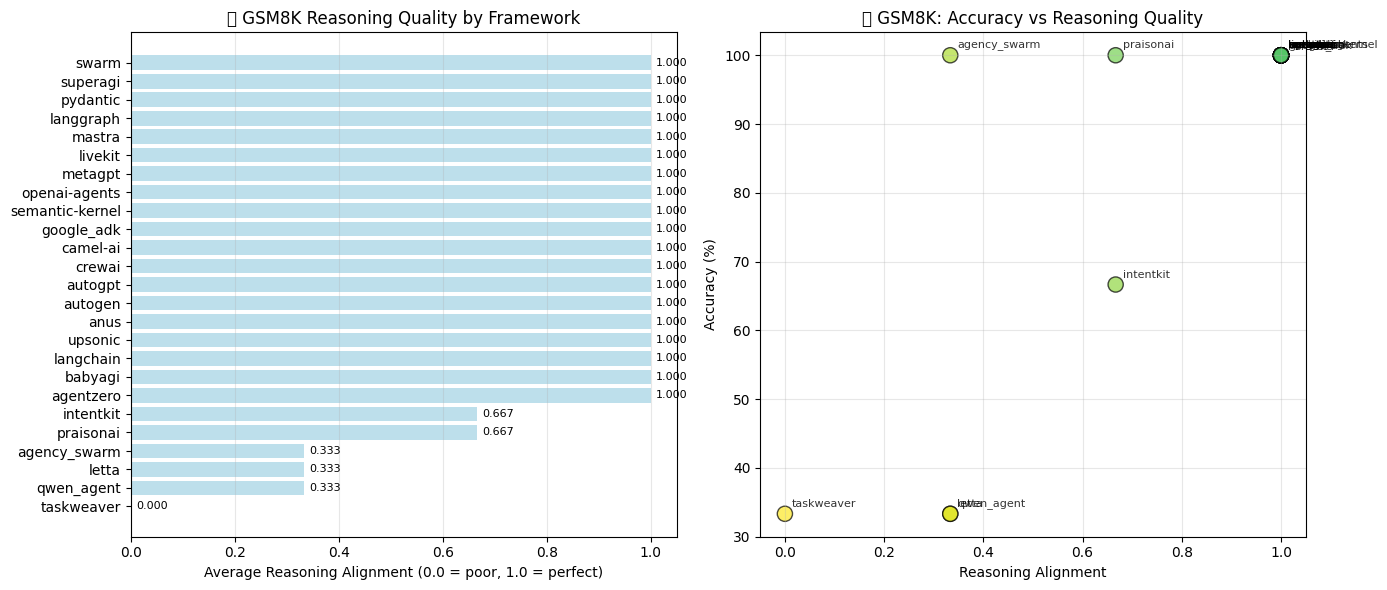


📈 Correlation between Reasoning Quality and Accuracy: 0.842


In [79]:
# GSM8K Reasoning Alignment Analysis
gsm8k = df[df['dataset'] == 'gsm8k']
if not gsm8k.empty and 'reasoning_alignment' in gsm8k.columns:
    has_reasoning = gsm8k['reasoning_alignment'].notna().any()
    
    if has_reasoning:
        reasoning_perf = gsm8k[gsm8k['reasoning_alignment'].notna()].groupby('framework').agg({
            'reasoning_alignment': 'mean',
            'overall_accuracy': 'first'
        }).sort_values('reasoning_alignment', ascending=False)
        
        print("🧠 GSM8K Reasoning Quality Analysis:")
        print("=" * 50)
        for fw, row in reasoning_perf.iterrows():
            print(f"{fw:15s} | Reasoning: {row['reasoning_alignment']:.3f} | Accuracy: {row['overall_accuracy']:.1f}%")
        
        # Reasoning-specific visualizations
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # 1. Reasoning alignment ranking
        reasoning_sorted = reasoning_perf.sort_values('reasoning_alignment', ascending=True)
        bars = axes[0].barh(reasoning_sorted.index, reasoning_sorted['reasoning_alignment'], 
                           color='lightblue', alpha=0.8)
        axes[0].set_xlabel('Average Reasoning Alignment (0.0 = poor, 1.0 = perfect)')
        axes[0].set_title('🧠 GSM8K Reasoning Quality by Framework')
        axes[0].grid(axis='x', alpha=0.3)
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            axes[0].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                        f'{width:.3f}', ha='left', va='center', fontsize=8)
        
        # 2. Accuracy vs Reasoning scatter plot
        axes[1].scatter(reasoning_perf['reasoning_alignment'], reasoning_perf['overall_accuracy'],
                       s=120, alpha=0.7, c=range(len(reasoning_perf)), cmap='viridis', edgecolor='black')
        axes[1].set_xlabel('Reasoning Alignment')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title('🎯 GSM8K: Accuracy vs Reasoning Quality')
        axes[1].grid(alpha=0.3)
        
        # Add framework labels to scatter plot
        for fw, row in reasoning_perf.iterrows():
            axes[1].annotate(fw, (row['reasoning_alignment'], row['overall_accuracy']),
                           xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
        
        plt.tight_layout()
        plt.savefig('gsm8k_reasoning_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Correlation analysis
        correlation = reasoning_perf['reasoning_alignment'].corr(reasoning_perf['overall_accuracy'])
        print(f"\n📈 Correlation between Reasoning Quality and Accuracy: {correlation:.3f}")
        
    else:
        print("❌ No GSM8K reasoning alignment data found")
else:
    print("❌ No GSM8K data available for reasoning analysis")

🏆 Overall Framework Ranking (Average):
 1. babyagi         100.0%
 2. langchain       100.0%
 3. anus             83.3%
 4. qwen_agent       83.3%
 5. pydantic         83.3%
 6. livekit          83.3%
 7. mastra           83.3%
 8. langgraph        83.3%
 9. openai-agents    83.3%
10. superagi         83.3%


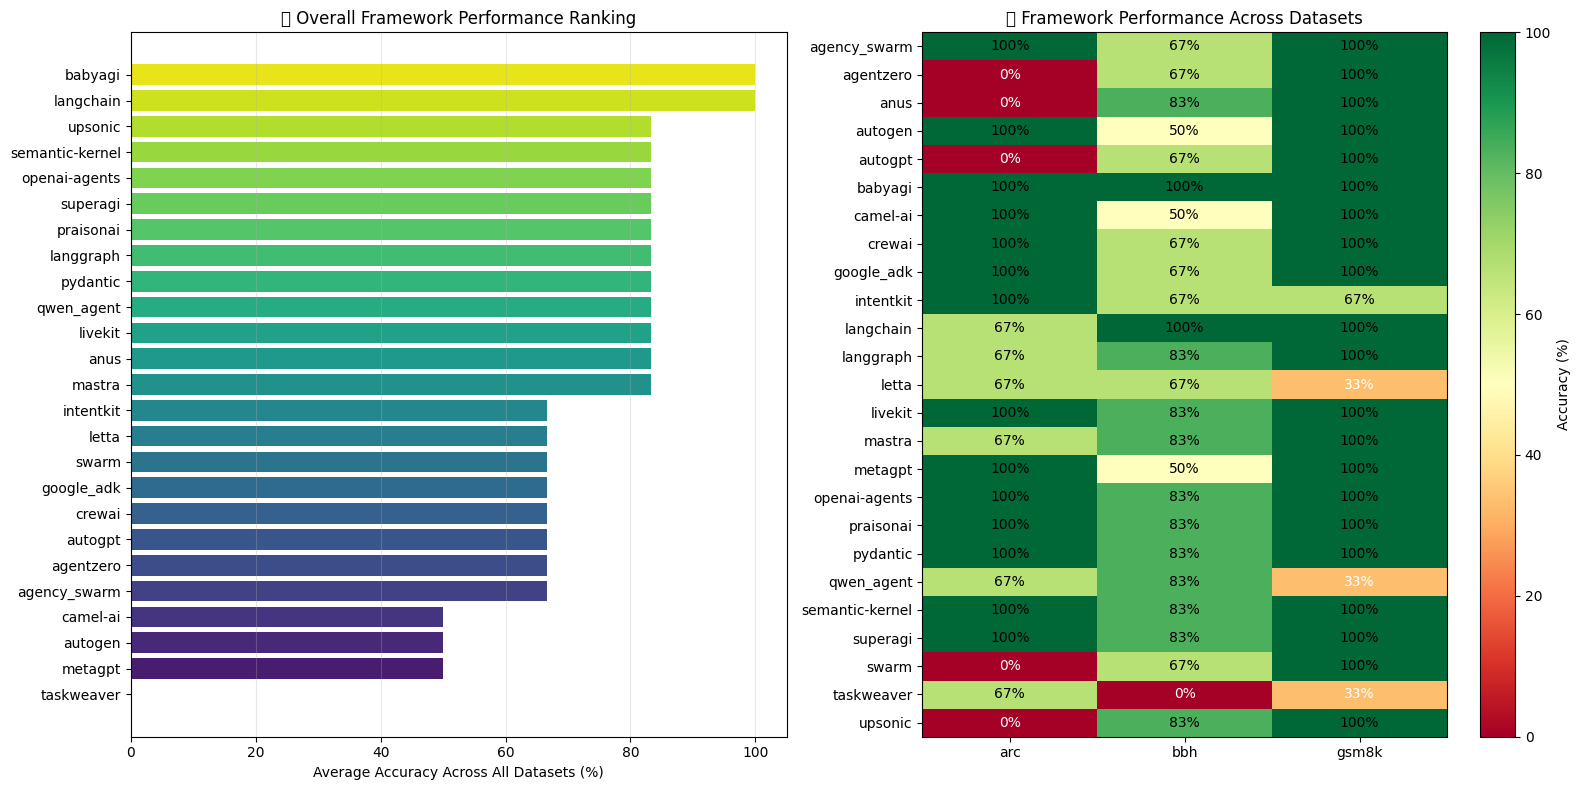

In [80]:
# Overall Comparison
if not df.empty:
    # Calculate average performance across datasets
    avg_perf = df.groupby('framework')['overall_accuracy'].first().sort_values(ascending=False)
    dataset_perf = df.groupby(['framework', 'dataset'])['overall_accuracy'].first().unstack(fill_value=0)
    
    print("🏆 Overall Framework Ranking (Average):")
    for i, (fw, acc) in enumerate(avg_perf.head(10).items(), 1):
        print(f"{i:2d}. {fw:15s} {acc:5.1f}%")
    
    # Cross-dataset comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Overall ranking
    avg_sorted = avg_perf.sort_values(ascending=True)
    axes[0].barh(avg_sorted.index, avg_sorted.values, color=sns.color_palette("viridis", len(avg_sorted)))
    axes[0].set_xlabel('Average Accuracy Across All Datasets (%)')
    axes[0].set_title('🏆 Overall Framework Performance Ranking')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Dataset comparison heatmap
    im = axes[1].imshow(dataset_perf.values, aspect='auto', cmap='RdYlGn')
    axes[1].set_xticks(range(len(dataset_perf.columns)))
    axes[1].set_xticklabels(dataset_perf.columns)
    axes[1].set_yticks(range(len(dataset_perf.index)))
    axes[1].set_yticklabels(dataset_perf.index)
    axes[1].set_title('📊 Framework Performance Across Datasets')
    
    # Add text annotations
    for i in range(len(dataset_perf.index)):
        for j in range(len(dataset_perf.columns)):
            value = dataset_perf.iloc[i, j]
            axes[1].text(j, i, f'{value:.0f}%', ha='center', va='center', 
                        color='white' if value < 50 else 'black')
    
    plt.colorbar(im, ax=axes[1], label='Accuracy (%)')
    plt.tight_layout()
    plt.savefig('overall_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("❌ No data available")

In [81]:
# Export Results
if not df.empty:
    # Summary table
    summary = df.groupby(['framework', 'dataset'])['overall_accuracy'].first().unstack(fill_value=0)
    summary['Average'] = summary.mean(axis=1)
    summary = summary.sort_values('Average', ascending=False)
    
    print("📊 Final Results Table:")
    print(summary.round(1))
    
    # Export to CSV
    summary.to_csv('framework_comparison.csv')
    df.to_csv('detailed_results.csv', index=False)
    
    print(f"\n✅ Exported framework_comparison.csv and detailed_results.csv")
    print(f"📊 Analysis complete: {df['framework'].nunique()} frameworks, {len(df)} questions")
else:
    print("❌ No data to export")

📊 Final Results Table:
dataset            arc    bbh  gsm8k  Average
framework                                    
babyagi          100.0  100.0  100.0    100.0
praisonai        100.0   83.3  100.0     94.4
pydantic         100.0   83.3  100.0     94.4
semantic-kernel  100.0   83.3  100.0     94.4
superagi         100.0   83.3  100.0     94.4
livekit          100.0   83.3  100.0     94.4
openai-agents    100.0   83.3  100.0     94.4
agency_swarm     100.0   66.7  100.0     88.9
crewai           100.0   66.7  100.0     88.9
langchain         66.7  100.0  100.0     88.9
google_adk       100.0   66.7  100.0     88.9
metagpt          100.0   50.0  100.0     83.3
camel-ai         100.0   50.0  100.0     83.3
autogen          100.0   50.0  100.0     83.3
mastra            66.7   83.3  100.0     83.3
langgraph         66.7   83.3  100.0     83.3
intentkit        100.0   66.7   66.7     77.8
anus               0.0   83.3  100.0     61.1
upsonic            0.0   83.3  100.0     61.1
qwen_agent 